### Задание 1 (синтаксис) ###
<pre> 
Для каждого покупателя получите таблицу со столбцами:
 • preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
 • total_spent - сумма всех трат;
 • addons_spent - сумма на дополнительные услуги и аксессуары;
 • orders_count - число заказов.
 
 Отсортируйте по total_spent по убыванию и выведите топ-10.

Пример вывода (формат; числа зависят от датасета):
</pre> 

<pre> 
customer_id  preferred_payment  total_spent  addons_spent  orders_count
 0         C042     Credit Card   15420.50        890.00             7
 1         C018     PayPal        14810.00        450.00             5
 2         C103     Debit Card    13990.25       1200.00             6
</pre>

<pre>
Пограничные случаи:

• Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
• Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
• Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
• Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.
</pre>

In [884]:
import pandas as pd

In [886]:
df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
             )

# Если в этих столбацах будут пропуски - удаляем строки из датасета
df = df.dropna(subset=["total_price", "payment_method"])

In [888]:
df.head(3)

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,add_ons_purchased,add_on_total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00


In [891]:
# Комментарий: метод mode() выводит значения в алфавитном порядке, если их несколько, поэтому mode()[0] вернет первое значение по алфавиту

new_df = df.groupby('customer_id').agg(preferred_payment=("payment_method", lambda values: values.mode()[0]) ,
                               total_spent=("total_price", "sum"),
                               addons_spent=("add_on_total", "sum") ,
                               orders_count=("purchase_date", "size")
                             ).sort_values('total_spent', ascending=False) \
                              .reset_index()

new_df.head(10)

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,34563.70,495.19,7
1,16863,PayPal,33035.92,486.17,5
2,13813,Credit Card,31830.16,268.64,5
3,11476,PayPal,31077.61,301.59,5
4,12276,Bank Transfer,30961.18,329.07,6
5,13635,Credit Card,30260.36,480.73,5
6,12749,Credit Card,29394.56,619.43,5
7,15399,PayPal,29084.88,305.39,3
8,12319,Bank Transfer,27352.32,226.38,3
9,19996,Bank Transfer,27296.78,432.12,6


### Задание 2 (повышенная сложность)
<pre>
Постройте пайплайн на Pandas (без циклов по строкам):
 
 1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.
 2. Метрики:
    • доход по методу доставки;
    • доход по типу продукта;
    • доход по доп. услугам: по месяцам и по кварталам;
    • cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
 3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.
 4. Выводы: несколько предложений по графикам. (?необязательно)
 
 Дополнительно: оформите шаги 1–2 как функции clean(df) → df и build_metrics(df) → dict[str, DataFrame].

Пример вывода метрик (фрагменты):

>>> metrics['revenue_by_shipping']
 shipping_method   revenue
 Express           125400.50
 Standard           98320.00
 Pickup             45110.75
 
 >>> metrics['addons_by_month'].head()
 month      addons_revenue
 2023-01           4200.00
 2023-02           3890.50
 2023-03           5100.00
 
 >>> metrics['cohort_revenue']  # строки — когорта, столбцы — месяц жизни 0..3
 cohort     0         1         2         3
 2023-01  15200.0   8100.0   4300.0   2100.0
 2023-02  14100.0   7600.0   3900.0      NaN
 ...

Графики: три отдельных figure/axes с подписями осей и заголовками. Числа в примере иллюстративные.

Пограничные случаи:

• Заказы с отрицательной или нулевой ценой - не должны попадать в доход после clean.
 • Покупатель с одним заказом - в когортной матрице заполнен только месяц 0.
 • Месяц без доп. услуг - в addons_by_month строка с 0 или отсутствие месяца (выберите и зафиксируйте поведение).
 • Пустой датасет после очистки → функции не падают, возвращают пустые таблицы.

</pre>


**1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.**

In [894]:
# переводим даты в datetime , удаляем строки с пропусками в полях нужных для выполнения задания 2 , 
# total_price и unit_price оставляем > 0, add_on_total >= 0


def clean(df):
    copy_df = df.copy()
    copy_df['purchase_date'] = pd.to_datetime(copy_df['purchase_date'], errors="coerce")
    copy_df = copy_df.dropna(subset=[    
        "customer_id",
        "purchase_date",
        "total_price",
        "unit_price",
        "shipping_type",
        "product_type",
        "add_on_total"]
        )
    copy_df = copy_df.query('total_price > 0 and unit_price > 0 and add_on_total >= 0')
    return copy_df.reset_index(drop=True)
    

In [895]:
clean_df = clean(df)


**2. Метрики:**

**• доход по методу доставки;**
    
**• доход по типу продукта;**
    
**• доход по доп. услугам: по месяцам и по кварталам;**
    
**• cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.**

In [900]:
def build_metrics(df):
    copy_df = df.copy()
    
    revenue_by_shipping = (
        copy_df.groupby('shipping_type')['total_price']
        .sum()
        .reset_index()
        .sort_values(by='total_price', ascending=False)
    )
    
    revenue_by_product = (
        copy_df.groupby('product_type')['total_price']
        .sum()
        .reset_index()
        .sort_values(by='total_price', ascending=False)
    )

    addons_by_month = (
        copy_df.groupby(copy_df['purchase_date'].dt.to_period('M'))['add_on_total']
        .sum()
        .reset_index()
    )

    addons_by_quarter = (
        copy_df.groupby(copy_df['purchase_date'].dt.to_period('Q'))['add_on_total']
        .sum()
        .reset_index()
    )

    copy_df['month'] = copy_df['purchase_date'].dt.to_period('M')
    copy_df['cohort'] = copy_df.groupby('customer_id')['month'].transform('min')

    copy_df['month_number'] = (
        (copy_df['month'].dt.year - copy_df['cohort'].dt.year) * 12
        + copy_df['month'].dt.month - copy_df['cohort'].dt.month
    )

    cohort_df = copy_df[copy_df['month_number'] <= 3]

    cohort_revenue = (
        cohort_df.groupby(['cohort', 'month_number'])['total_price']
        .sum()
        .unstack()
        .reindex(columns=[0, 1, 2, 3])
    )

    cohort_customers = (
        cohort_df.groupby(['cohort', 'month_number'])['customer_id']
        .nunique()
        .unstack()
        .reindex(columns=[0, 1, 2, 3])
    )

    return {
        'revenue_by_shipping': revenue_by_shipping,
        'revenue_by_product': revenue_by_product,
        'addons_by_month': addons_by_month,
        'addons_by_quarter': addons_by_quarter,
        'cohort_revenue': cohort_revenue,
        'cohort_customers': cohort_customers,
    }

In [902]:
metrics = build_metrics(clean_df)

In [904]:
metrics['revenue_by_shipping']

,shipping_type,total_price
4,Standard,21343073.55
0,Expedited,12437526.21
3,Same Day,12432024.82
2,Overnight,8704828.17
1,Express,8685215.62


In [906]:
metrics['revenue_by_product']

,product_type,total_price
2,Smartphone,21516754.69
3,Smartwatch,14036273.06
1,Laptop,12296239.97
4,Tablet,11712000.41
0,Headphones,4041400.24


In [908]:
metrics['cohort_revenue']

month_number,0,1,2,3
cohort,,,,
2023-09,481961.79,50514.74,47257.20,51120.20
2023-10,2267951.61,155302.95,239168.06,199974.25
2023-11,1865873.99,128478.44,186910.97,98007.62
2023-12,1561933.63,154981.79,105574.15,114670.83
2024-01,6034006.07,563400.17,723336.79,672185.51
2024-02,4734162.29,491320.81,527889.65,607050.30
2024-03,4631455.70,550615.28,488574.18,489712.08
2024-04,4122813.88,396920.86,511530.09,490340.42
2024-05,3870243.83,377504.74,515389.20,345730.60


**3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.**

In [911]:
clean_df.head(1)

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,add_ons_purchased,add_on_total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21


In [913]:
import matplotlib.pyplot as plt
import seaborn as sns

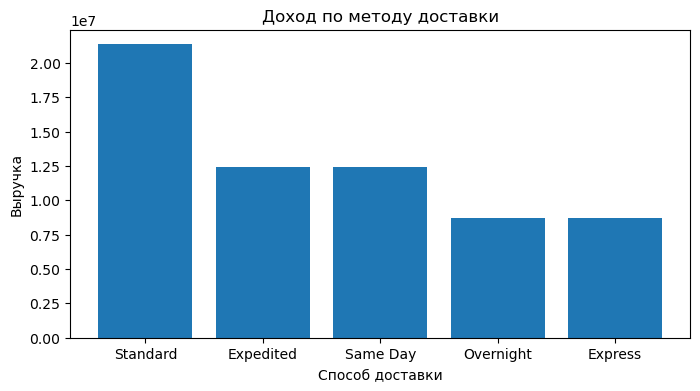

In [915]:
plt.figure(figsize=(8, 4))
plt.bar(
    metrics['revenue_by_shipping']['shipping_type'],
    metrics['revenue_by_shipping']['total_price']
)
plt.title('Доход по методу доставки')
plt.xlabel('Способ доставки')
plt.ylabel('Выручка')
plt.show()

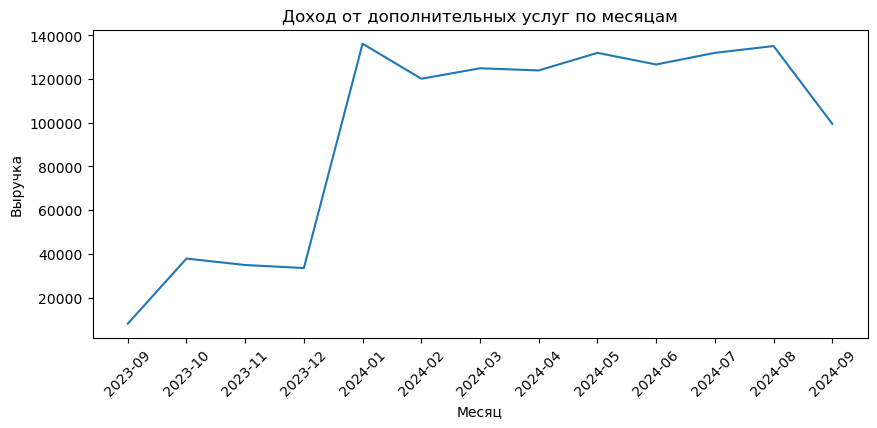

In [916]:
plt.figure(figsize=(10, 4))
plt.plot(
    metrics['addons_by_month']['purchase_date'].astype(str),
    metrics['addons_by_month']['add_on_total']
)
plt.title('Доход от дополнительных услуг по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.show()

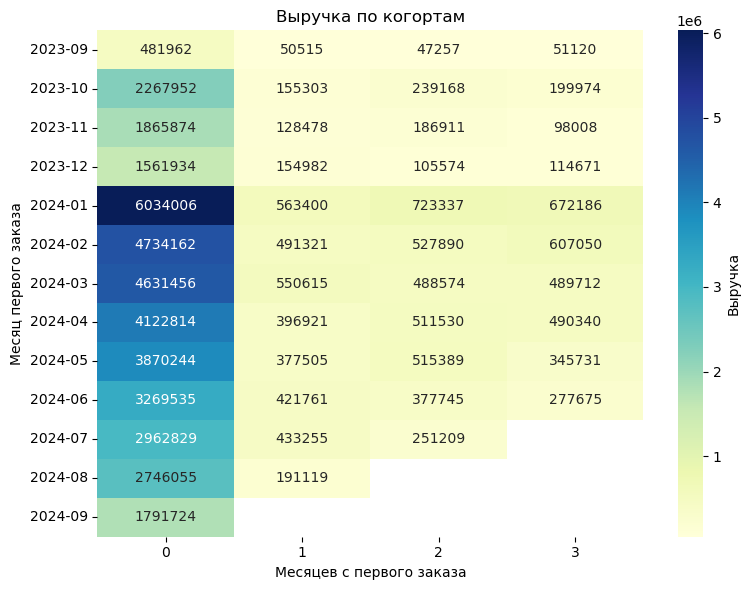

In [918]:
plt.figure(figsize=(8, 6))
sns.heatmap(metrics['cohort_revenue'], annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Выручка'}
)
plt.title('Выручка по когортам')
plt.xlabel('Месяцев с первого заказа')
plt.ylabel('Месяц первого заказа')
plt.tight_layout()
plt.show()

**4. Выводы: несколько предложений по графикам. (?необязательно)**

Больше всего выручки принесли заказы с доставкой Standard, меньше - Overnight и Express

Доход от доп.услуг резко вырос в январе 2024 года и дежрался на примерно одном уровне до сентября, в сентябре снизился

Больше всего денег приносят покупатели в первый месяц покупки, наимбольшую выручку принесла когорта в январе 2024